In [4]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Embedding, GRU, Dropout

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split

In [8]:
from google.colab import files

print("Please upload the 'ADA-USD.csv' file.")
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

Please upload the 'ADA-USD.csv' file.


Saving ADA-USD.csv to ADA-USD.csv


In [9]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.025160,0.035060,0.025006,0.032053,0.032053,18716200
1,2017-11-10,0.032219,0.033348,0.026451,0.027119,0.027119,6766780
2,2017-11-11,0.026891,0.029659,0.025684,0.027437,0.027437,5532220
3,2017-11-12,0.027480,0.027952,0.022591,0.023977,0.023977,7280250
4,2017-11-13,0.024364,0.026300,0.023495,0.025808,0.025808,4419440


In [10]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [11]:
data = df[['Close']]

data.head()

,Close
0,0.032053
1,0.027119
2,0.027437
3,0.023977
4,0.025808


In [12]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [13]:
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1538, 60)
(1538,)


In [14]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(1538, 60, 1)


In [15]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [16]:
model = Sequential()

model.add(
    GRU(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)
model.add(GRU(units=64))

model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 3.3351e-04 - val_loss: 0.0019
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 3.0273e-04 - val_loss: 0.0018
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 2.5227e-04 - val_loss: 0.0027
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 3.2599e-04 - val_loss: 0.0014
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 2.7290e-04 - val_loss: 0.0014
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 2.5505e-04 - val_loss: 0.0014
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 2.3818e-04 - val_loss: 0.0015
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 2.2564e-04 - val_loss: 0.0017
Epoch 10/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 1.9396e-04 - val_loss: 0.0011
Epoch 11/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.0034e-04 - val_loss: 0.0012
Epoch 12/20
39/39 ━━━━━

In [19]:
predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [20]:
predictions = scaler.inverse_transform(predictions.reshape(-1,1))

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [21]:
rmse = np.sqrt(
    mean_squared_error(actual,predictions)
)

mae = mean_absolute_error(actual,predictions)

print("RMSE:", rmse)
print("MAE :", mae)

RMSE: 0.12003081684885951
MAE : 0.09852298396707515


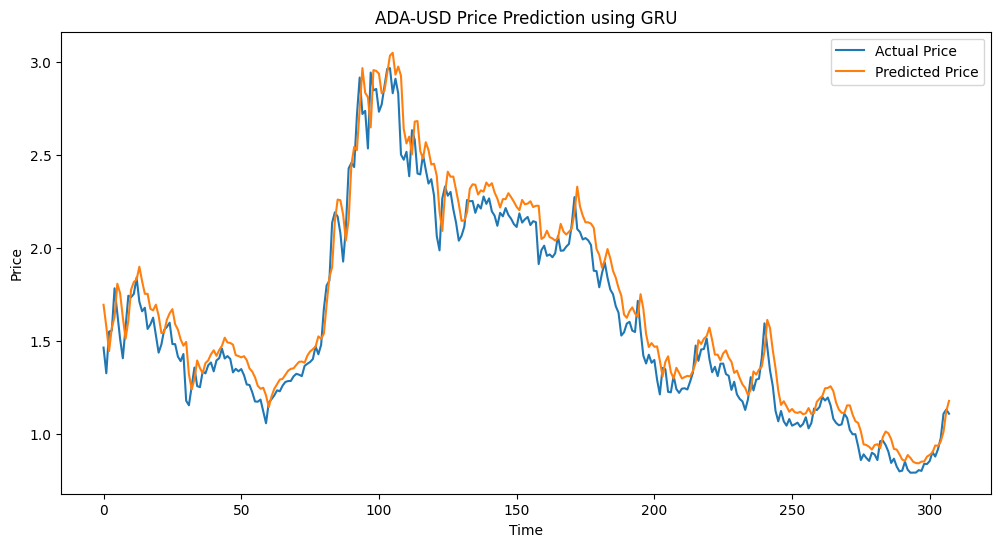

In [22]:
plt.figure(figsize=(12,6))

plt.plot(actual,label='Actual Price')
plt.plot(predictions,label='Predicted Price')

plt.title('ADA-USD Price Prediction using GRU')
plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()
plt.show()